<a href="https://colab.research.google.com/github/scudilio/FACENS/blob/main/clustering_kmeans_facens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔵 Clustering & K-Means — Aula Prática


---

## 📚 Objetivos deste Notebook

Este notebook cobre dois casos de uso reais de clustering:

1. **Segmentação de Clientes** — dataset Mall Customers (Kaggle)  
   → Identificar perfis de consumidores para estratégias de marketing personalizadas

2. **Detecção de Anomalias** — dataset Credit Card Fraud (versão reduzida / sintética)  
   → Usar clustering para encontrar comportamentos atípicos (não supervisionado)

---

## 📦 Estrutura do Notebook

```
PARTE 1 — Setup & Teoria Rápida
PARTE 2 — Caso 1: Segmentação de Clientes
   2.1 Carregamento e EDA
   2.2 Pré-processamento
   2.3 Escolhendo K (Elbow + Silhouette)
   2.4 K-Means: treinamento e análise
   2.5 Visualização 2D e 3D
   2.6 Profiling dos Clusters
PARTE 3 — Caso 2: Detecção de Anomalias
   3.1 Dataset e contexto
   3.2 Abordagem: clustering + distância ao centróide
   3.3 Isolation Forest como comparação
   3.4 Avaliação e métricas
```

## PARTE 1 — Setup & Instalação de Dependências

In [ ]:
# Instalar dependências (execute uma vez)
# !pip install kagglehub scikit-learn pandas numpy matplotlib seaborn plotly -q

In [16]:
# ─── Imports principais ───────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np # manipulacao algebricas
import pandas as pd # processamento dataframe
import matplotlib.pyplot as plt # visualizacao de dados
import matplotlib.cm as cm # visualizacao de dados
import seaborn as sns # visualizacao de dados

from sklearn.preprocessing import StandardScaler, LabelEncoder #tratamento de dados
from sklearn.cluster import KMeans, DBSCAN #algoritmo de machine learning nao surpervisionado para clusterizacao
from sklearn.ensemble import IsolationForest #deteccao de anomalias
from sklearn.decomposition import PCA #reducao de dimensao
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, confusion_matrix, classification_report
) #metricas de avaliacao
from sklearn.manifold import TSNE

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Seed global para reproducibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paleta Facens
#FACENS_COLORS = ['#002D62', '#00579B', '#00A8E0', '#4FC3F7', '#8DB4D6', '#E8EFF8']
FACENS_COLORS =['#813AE8', '#E83AD5', '#E83A6C', '#4FC3F7', '#8DB4D6', '#E8EFF8']
sns.set_palette(FACENS_COLORS)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('✅ Imports realizados com sucesso!')
print(f'scikit-learn version: {__import__("sklearn").__version__}')

✅ Imports realizados com sucesso!
scikit-learn version: 1.6.1


---
## PARTE 2 — Caso 1: Segmentação de Clientes (Mall Customers)

### 📌 Contexto de Negócio

Um shopping center deseja entender o perfil de seus clientes para:
- Personalizar campanhas de marketing
- Otimizar o layout das lojas
- Criar programas de fidelidade segmentados

O dataset contém informações de **200 clientes** com as seguintes variáveis:

| Coluna | Descrição |
|--------|-----------|
| `CustomerID` | Identificador único |
| `Genre` | Gênero (Male/Female) |
| `Age` | Idade |
| `Annual Income (k$)` | Renda anual em mil dólares |
| `Spending Score (1-100)` | Score de propensão a gastar (definido pelo shopping) |

**Origem:** [Kaggle - Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

### 2.1 Carregamento dos Dados

In [2]:
# ─── Opção 1: Download via KaggleHub ─────────────────────────────────────────
try:
    import kagglehub
    path = kagglehub.dataset_download('vjchoudhary7/customer-segmentation-tutorial-in-python')
    df = pd.read_csv(f'{path}/Mall_Customers.csv')
    print(f'✅ Dataset carregado via KaggleHub: {path}')
except Exception:
    # ─── Opção 2: Geração sintética fiel ao dataset original ─────────────────
    print('⚠️  KaggleHub não disponível. Gerando dataset sintético equivalente...')
    np.random.seed(42)
    n = 200
    genres = np.random.choice(['Male', 'Female'], n, p=[0.44, 0.56])
    ages = np.clip(np.random.normal(38, 13, n).astype(int), 18, 70)
    incomes = np.clip(np.random.normal(60, 26, n).astype(int), 15, 137)

    # Scores com estrutura de clusters para garantir resultado esperado
    scores = []
    for inc in incomes:
        if inc < 40:
            scores.append(int(np.clip(np.random.normal(70, 15), 1, 99)))
        elif inc < 70:
            scores.append(int(np.clip(np.random.normal(50, 20), 1, 99)))
        else:
            r = np.random.rand()
            if r < 0.4:
                scores.append(int(np.clip(np.random.normal(82, 8), 1, 99)))
            else:
                scores.append(int(np.clip(np.random.normal(18, 8), 1, 99)))

    df = pd.DataFrame({
        'CustomerID': range(1, n+1),
        'Genre': genres,
        'Age': ages,
        'Annual Income (k$)': incomes,
        'Spending Score (1-100)': scores
    })
    print('✅ Dataset sintético gerado com sucesso.')

print(f'\nShape: {df.shape}')
df.head(10)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
✅ Dataset carregado via KaggleHub: /kaggle/input/customer-segmentation-tutorial-in-python

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


### 2.2 Análise Exploratória (EDA)

Antes de aplicar qualquer algoritmo, precisamos entender a distribuição dos dados, identificar possíveis outliers e verificar correlações. Esta etapa é fundamental para escolher as features mais relevantes para o clustering.

In [3]:
# ─── Estatísticas descritivas ─────────────────────────────────────────────────
print('=== Informações do Dataset ===')
print(df.info())
print('\n=== Valores Nulos ===')
print(df.isnull().sum())
print('\n=== Estatísticas Descritivas ===')
df.describe().round(2)

=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

=== Valores Nulos ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Estatísticas Descritivas ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


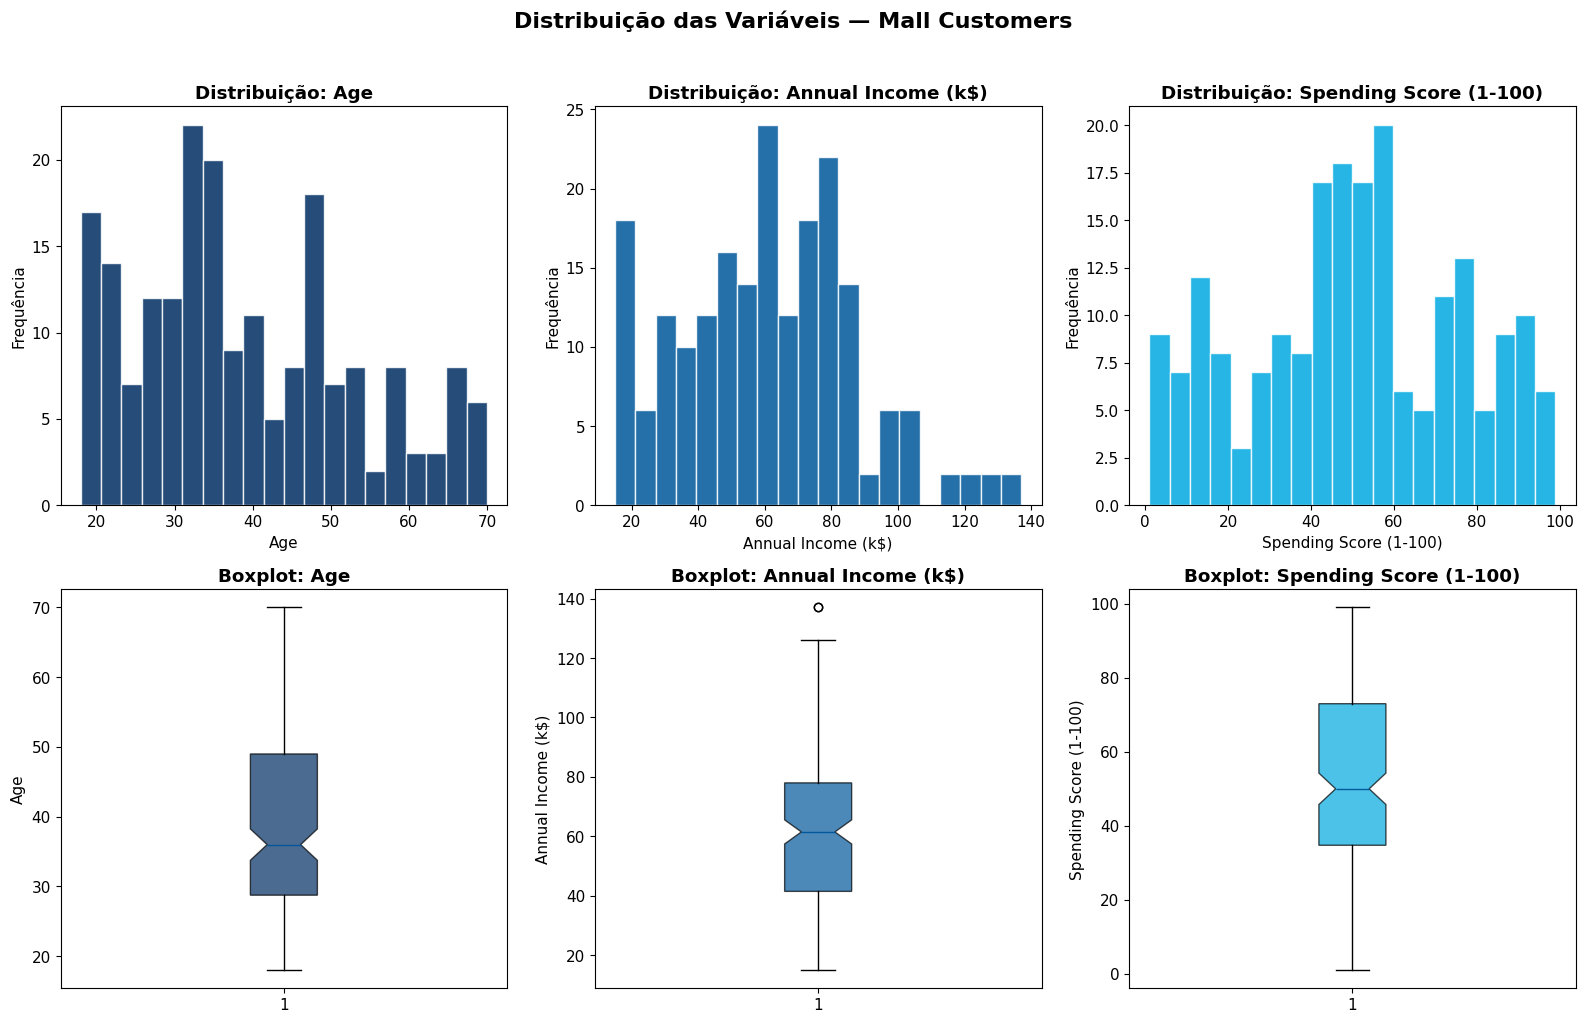

💡 Observação: Identificar bimodalidade no Spending Score sugere subgrupos naturais.


In [4]:
# ─── Visualização das distribuições ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuição das Variáveis — Mall Customers', fontsize=16, fontweight='bold', y=1.02)

features_num = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = FACENS_COLORS[:3]

for i, (feat, col) in enumerate(zip(features_num, colors)):
    # Histograma
    axes[0, i].hist(df[feat], bins=20, color=col, edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'Distribuição: {feat}', fontweight='bold')
    axes[0, i].set_xlabel(feat)
    axes[0, i].set_ylabel('Frequência')

    # Boxplot
    bp = axes[1, i].boxplot(df[feat], patch_artist=True, notch=True)
    bp['boxes'][0].set_facecolor(col)
    bp['boxes'][0].set_alpha(0.7)
    axes[1, i].set_title(f'Boxplot: {feat}', fontweight='bold')
    axes[1, i].set_ylabel(feat)

plt.tight_layout()
plt.savefig('eda_distribuicoes.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Observação: Identificar bimodalidade no Spending Score sugere subgrupos naturais.')

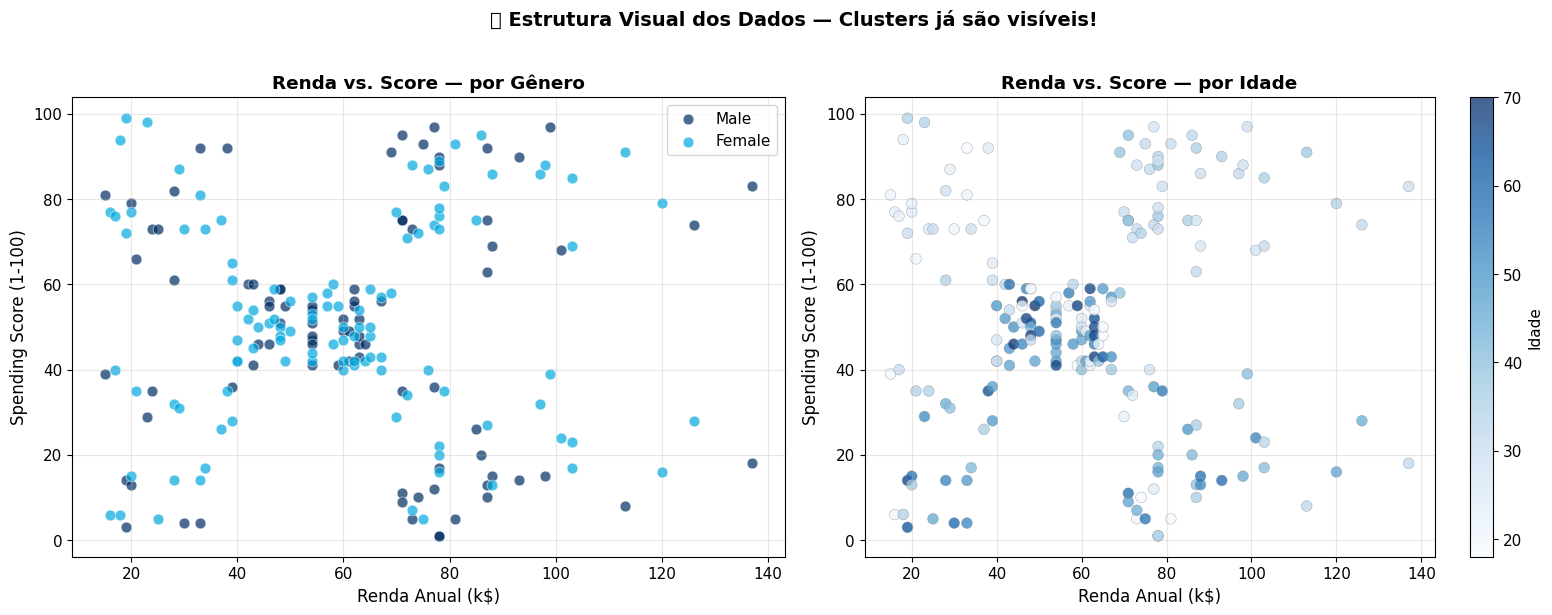

In [6]:
# ─── Scatter plot: Renda vs Score (o "canvas" principal do clustering) ────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por gênero
for genre, col in zip(['Male', 'Female'], [FACENS_COLORS[0], FACENS_COLORS[2]]):
    subset = df[df['Gender'] == genre]
    axes[0].scatter(
        subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
        c=col, label=genre, alpha=0.7, s=60, edgecolors='white', linewidth=0.5
    )
axes[0].set_xlabel('Renda Anual (k$)', fontsize=12)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[0].set_title('Renda vs. Score — por Gênero', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Por Idade (colormap)
sc = axes[1].scatter(
    df['Annual Income (k$)'], df['Spending Score (1-100)'],
    c=df['Age'], cmap='Blues', alpha=0.75, s=60, edgecolors='gray', linewidth=0.3
)
plt.colorbar(sc, ax=axes[1], label='Idade')
axes[1].set_xlabel('Renda Anual (k$)', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[1].set_title('Renda vs. Score — por Idade', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('🔍 Estrutura Visual dos Dados — Clusters já são visíveis!', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_renda_score.png', dpi=150, bbox_inches='tight')
plt.show()

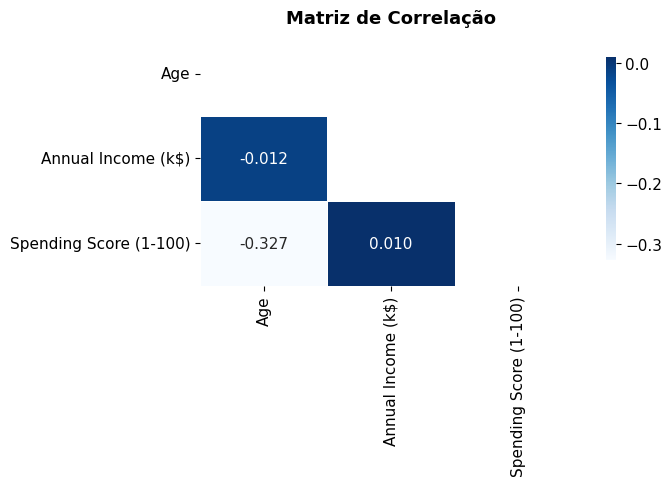

💡 Correlações baixas entre Renda e Score → as duas features carregam informação independente.


In [7]:
# ─── Matriz de correlação ─────────────────────────────────────────────────────
df_numeric = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = df_numeric.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', mask=mask,
    cmap='Blues', ax=ax, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlação', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print('💡 Correlações baixas entre Renda e Score → as duas features carregam informação independente.')

### 2.3 Pré-Processamento

**Por que normalizar é obrigatório para K-Means?**

K-Means usa distância Euclidiana. Se uma feature tem escala de 0–100 e outra de 0–1.000.000, a segunda **dominará completamente** o cálculo de distância, fazendo a primeira se tornar irrelevante.

**Fórmula do StandardScaler:**
$$z = \frac{x - \mu}{\sigma}$$

Após a normalização: $\mu = 0$, $\sigma = 1$ para todas as features.

In [8]:
# ─── Seleção de features e normalização ──────────────────────────────────────

# Features selecionadas para clustering
# Usamos Renda e Score — as duas mais informativas conforme EDA
FEATURES = ['Annual Income (k$)', 'Spending Score (1-100)','Age']

X = df[FEATURES].values

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificação: antes vs depois
comparison = pd.DataFrame({
    'Renda_original_mean': [X[:, 0].mean()],
    'Renda_original_std':  [X[:, 0].std()],
    'Renda_scaled_mean':   [X_scaled[:, 0].mean()],
    'Renda_scaled_std':    [X_scaled[:, 0].std()],
    'Score_original_mean': [X[:, 1].mean()],
    'Score_original_std':  [X[:, 1].std()],
    'Score_scaled_mean':   [X_scaled[:, 1].mean()],
    'Score_scaled_std':    [X_scaled[:, 1].std()],
}).T.rename(columns={0: 'Valor'})

print('=== Antes vs. Depois do StandardScaler ===')
print(comparison.round(4))
print(f'\n✅ Shape X_scaled: {X_scaled.shape}')

=== Antes vs. Depois do StandardScaler ===
                       Valor
Renda_original_mean  60.5600
Renda_original_std   26.1990
Renda_scaled_mean    -0.0000
Renda_scaled_std      1.0000
Score_original_mean  50.2000
Score_original_std   25.7589
Score_scaled_mean    -0.0000
Score_scaled_std      1.0000

✅ Shape X_scaled: (200, 3)


### 2.4 Escolhendo K — Elbow Method + Silhouette Score

**Método do Cotovelo (Elbow):**  
Plotamos o WCSS (Within-Cluster Sum of Squares) para cada valor de K. O "cotovelo" indica onde o ganho de redução de WCSS começa a diminuir significativamente.

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

**Silhouette Score:**  
Avalia simultaneamente coesão interna e separação entre clusters.

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Onde $a(i)$ = distância média intra-cluster e $b(i)$ = distância média ao cluster vizinho mais próximo.

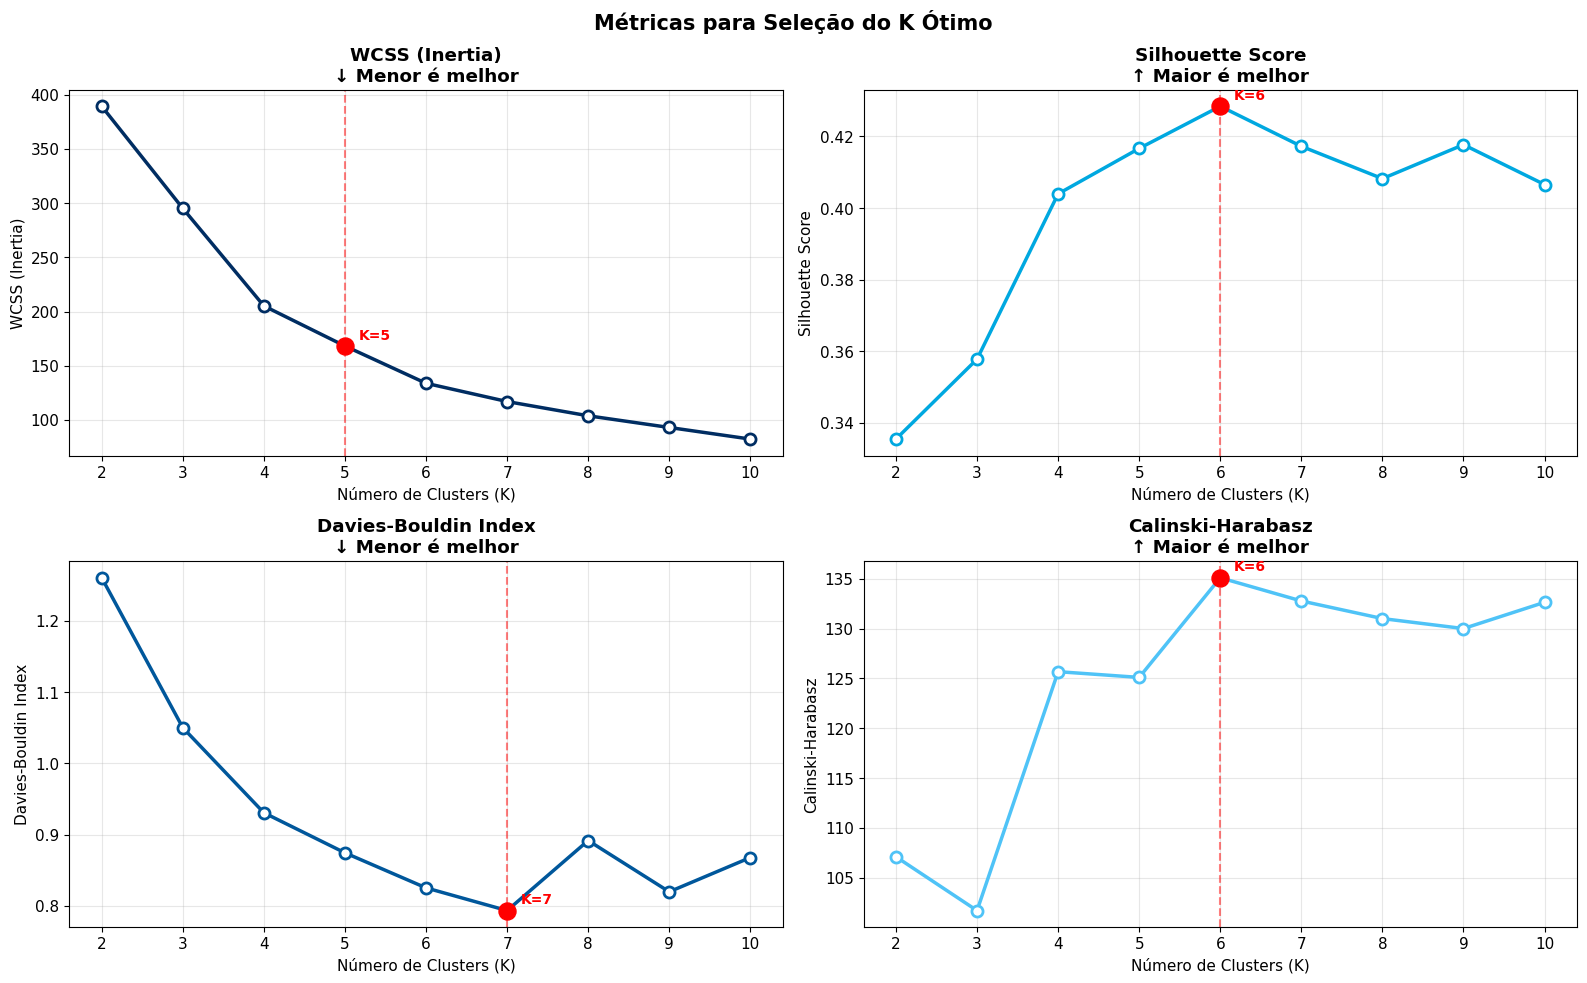


Resumo das métricas:
 K     WCSS  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2 389.3862      0.3355          1.2607           107.0956
 3 295.2122      0.3578          1.0503           101.6949
 4 205.2251      0.4040          0.9308           125.6764
 5 168.2476      0.4166          0.8746           125.1009
 6 133.8684      0.4284          0.8254           135.1021
 7 117.0116      0.4172          0.7935           132.7743
 8 103.8733      0.4082          0.8918           131.0062
 9  93.0929      0.4177          0.8198           130.0036
10  82.3852      0.4066          0.8679           132.6383


In [9]:
# ─── Cálculo do Elbow e Silhouette para K de 2 a 10 ─────────────────────────
K_range = range(2, 11)
wcss_list = []
sil_list = []
dbi_list = []
ch_list = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_scaled)

    wcss_list.append(kmeans.inertia_)
    sil_list.append(silhouette_score(X_scaled, labels))
    dbi_list.append(davies_bouldin_score(X_scaled, labels))
    ch_list.append(calinski_harabasz_score(X_scaled, labels))

# ─── Plot das métricas ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Métricas para Seleção do K Ótimo', fontsize=15, fontweight='bold')

metrics = [
    (wcss_list, 'WCSS (Inertia)', '↓ Menor é melhor', FACENS_COLORS[0], axes[0,0]),
    (sil_list,  'Silhouette Score', '↑ Maior é melhor', FACENS_COLORS[2], axes[0,1]),
    (dbi_list,  'Davies-Bouldin Index', '↓ Menor é melhor', FACENS_COLORS[1], axes[1,0]),
    (ch_list,   'Calinski-Harabasz', '↑ Maior é melhor', FACENS_COLORS[3], axes[1,1]),
]

for values, title, subtitle, color, ax in metrics:
    ks = list(K_range)
    ax.plot(ks, values, 'o-', color=color, linewidth=2.5, markersize=8, markerfacecolor='white',
            markeredgewidth=2)
    # Marcar K ótimo
    best_idx = values.index(max(values)) if '↑' in subtitle else values.index(min(values))
    # Para WCSS, o ótimo não é mínimo diretamente — marcamos K=5 (cotovelo esperado)
    if title == 'WCSS (Inertia)':
        best_idx = 3  # K=5
    ax.axvline(x=ks[best_idx], color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.scatter([ks[best_idx]], [values[best_idx]], color='red', s=150, zorder=5)
    ax.annotate(f'K={ks[best_idx]}', (ks[best_idx], values[best_idx]),
                textcoords='offset points', xytext=(10, 5), fontsize=10,
                color='red', fontweight='bold')
    ax.set_title(f'{title}\n{subtitle}', fontweight='bold')
    ax.set_xlabel('Número de Clusters (K)')
    ax.set_ylabel(title)
    ax.set_xticks(ks)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('metricas_k_otimo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nResumo das métricas:')
results_df = pd.DataFrame({'K': list(K_range), 'WCSS': wcss_list, 'Silhouette': sil_list,
                            'Davies-Bouldin': dbi_list, 'Calinski-Harabasz': ch_list})
print(results_df.round(4).to_string(index=False))

In [11]:
# ─── Silhouette Plot detalhado para K=5 ──────────────────────────────────────
K_BEST = 5

kmeans_best = KMeans(n_clusters=K_BEST, init='k-means++', n_init=10, random_state=RANDOM_STATE) #definindo o algoritmo de agrupamento
labels_best = kmeans_best.fit_predict(X_scaled) # buscando padroes nos dados (aprendendo com os dados)


In [12]:
labels_best

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

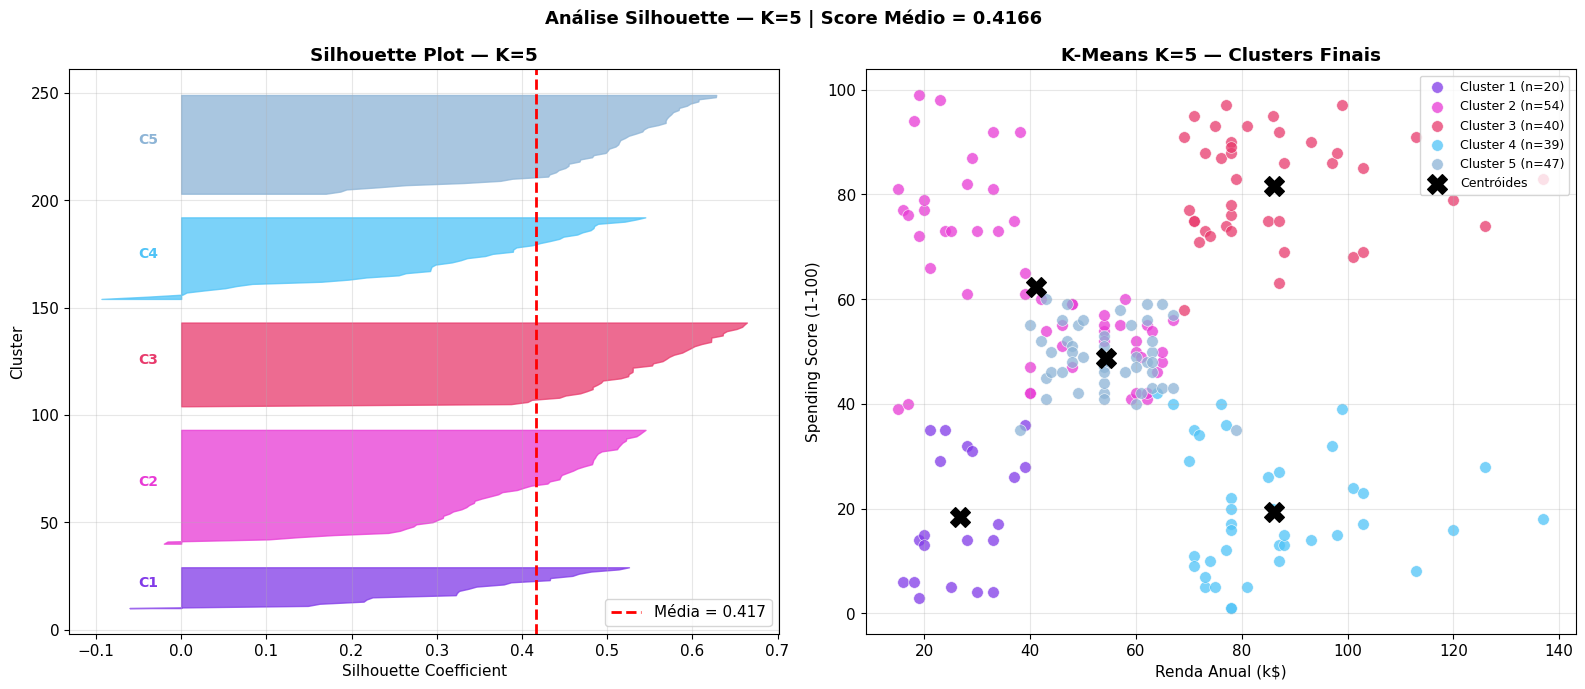

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Silhouette plot detalhado (cada amostra)
sil_values = silhouette_samples(X_scaled, labels_best)
sil_avg = sil_values.mean()

ax1 = axes[0]
y_lower = 10
cluster_colors = [FACENS_COLORS[i % len(FACENS_COLORS)] for i in range(K_BEST)]

for i in range(K_BEST):
    ith_cluster_sil = np.sort(sil_values[labels_best == i])
    size_i = ith_cluster_sil.shape[0]
    y_upper = y_lower + size_i
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil,
                      facecolor=cluster_colors[i], edgecolor=cluster_colors[i], alpha=0.75)
    ax1.text(-0.05, y_lower + 0.5 * size_i, f'C{i+1}', fontsize=10, color=cluster_colors[i], fontweight='bold')
    y_lower = y_upper + 10

ax1.axvline(x=sil_avg, color='red', linestyle='--', linewidth=2, label=f'Média = {sil_avg:.3f}')
ax1.set_xlabel('Silhouette Coefficient')
ax1.set_ylabel('Cluster')
ax1.set_title(f'Silhouette Plot — K={K_BEST}', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Scatter com clusters
ax2 = axes[1]
for i in range(K_BEST):
    mask_c = labels_best == i
    ax2.scatter(X[mask_c, 0], X[mask_c, 1], c=cluster_colors[i],
                label=f'Cluster {i+1} (n={mask_c.sum()})', alpha=0.75, s=70,
                edgecolors='white', linewidth=0.5)

# Centróides (na escala original)
centroids_orig = scaler.inverse_transform(kmeans_best.cluster_centers_)
ax2.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            c='black', marker='X', s=200, zorder=10, label='Centróides')
ax2.set_xlabel('Renda Anual (k$)')
ax2.set_ylabel('Spending Score (1-100)')
ax2.set_title(f'K-Means K={K_BEST} — Clusters Finais', fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle(f'Análise Silhouette — K={K_BEST} | Score Médio = {sil_avg:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('silhouette_k5.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Treinamento Final e Profiling dos Clusters

Com K=5 selecionado, treinamos o modelo final e analisamos o perfil de cada cluster para gerar **insights de negócio**.

In [19]:
# ─── Adicionar cluster labels ao DataFrame original ───────────────────────────
df['Cluster'] = labels_best
df['Cluster_Nome'] = df['Cluster'].map({
    0: 'Cluster A', 1: 'Cluster B', 2: 'Cluster C',
    3: 'Cluster D', 4: 'Cluster E'
})

# Profiling estatístico
print('=== Perfil Estatístico por Cluster ===')
profile = df.groupby('Cluster').agg(
    n_clientes=('CustomerID', 'count'),
    idade_media=('Age', 'mean'),
    renda_media=('Annual Income (k$)', 'mean'),
    score_medio=('Spending Score (1-100)', 'mean'),
    pct_feminino=('Gender', lambda x: (x == 'Female').mean() * 100)
).round(1)
print(profile)

# Inertia e Silhouette finais
print(f'\n📊 Métricas do Modelo Final (K={K_BEST}):')
print(f'   WCSS (Inertia):       {kmeans_best.inertia_:.2f}')
print(f'   Silhouette Score:     {silhouette_score(X_scaled, labels_best):.4f}')
print(f'   Davies-Bouldin:       {davies_bouldin_score(X_scaled, labels_best):.4f}')
print(f'   Calinski-Harabasz:    {calinski_harabasz_score(X_scaled, labels_best):.2f}')

=== Perfil Estatístico por Cluster ===
         n_clientes  idade_media  renda_media  score_medio  pct_feminino
Cluster                                                                 
0                20         46.2         26.8         18.4          60.0
1                54         25.2         41.1         62.2          59.3
2                40         32.9         86.1         81.5          55.0
3                39         39.9         86.1         19.4          48.7
4                47         55.6         54.4         48.9          57.4

📊 Métricas do Modelo Final (K=5):
   WCSS (Inertia):       168.25
   Silhouette Score:     0.4166
   Davies-Bouldin:       0.8746
   Calinski-Harabasz:    125.10


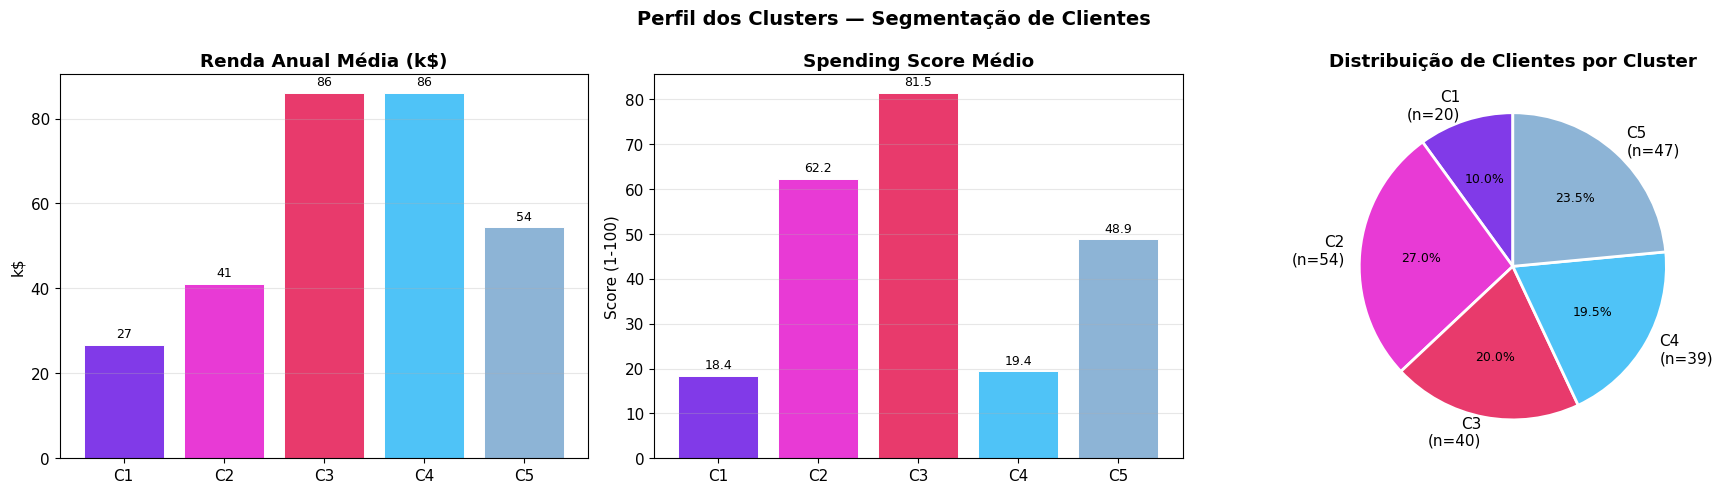

In [20]:
# ─── Visualização do Profiling — Radar / Barras por Cluster ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Perfil dos Clusters — Segmentação de Clientes', fontsize=14, fontweight='bold')

cluster_colors_map = {i: FACENS_COLORS[i % len(FACENS_COLORS)] for i in range(K_BEST)}
cluster_labels_map = {i: f'C{i+1}' for i in range(K_BEST)}

# Renda média por cluster
renda_por_cluster = df.groupby('Cluster')['Annual Income (k$)'].mean()
bars0 = axes[0].bar([cluster_labels_map[i] for i in renda_por_cluster.index],
                     renda_por_cluster.values,
                     color=[cluster_colors_map[i] for i in renda_por_cluster.index],
                     edgecolor='white', linewidth=0.7)
axes[0].set_title('Renda Anual Média (k$)', fontweight='bold')
axes[0].set_ylabel('k$')
axes[0].bar_label(bars0, fmt='%.0f', padding=3, fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Spending Score médio por cluster
score_por_cluster = df.groupby('Cluster')['Spending Score (1-100)'].mean()
bars1 = axes[1].bar([cluster_labels_map[i] for i in score_por_cluster.index],
                     score_por_cluster.values,
                     color=[cluster_colors_map[i] for i in score_por_cluster.index],
                     edgecolor='white', linewidth=0.7)
axes[1].set_title('Spending Score Médio', fontweight='bold')
axes[1].set_ylabel('Score (1-100)')
axes[1].bar_label(bars1, fmt='%.1f', padding=3, fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Tamanho dos clusters
tamanho = df.groupby('Cluster').size()
wedges, texts, autotexts = axes[2].pie(
    tamanho.values,
    labels=[f'C{i+1}\n(n={v})' for i, v in zip(tamanho.index, tamanho.values)],
    colors=[cluster_colors_map[i] for i in tamanho.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(9)
axes[2].set_title('Distribuição de Clientes por Cluster', fontweight='bold')

plt.tight_layout()
plt.savefig('perfil_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ─── Interpretação dos Clusters ───────────────────────────────────────────────
profile_full = df.groupby('Cluster').agg(
    n_clientes=('CustomerID', 'count'),
    idade_media=('Age', 'mean'),
    renda_media=('Annual Income (k$)', 'mean'),
    score_medio=('Spending Score (1-100)', 'mean'),
).round(1)

# Atribuir nomes descritivos baseados nos centróides
for idx, row in profile_full.iterrows():
    renda = row['renda_media']
    score = row['score_medio']

    if renda > 70 and score > 60:
        nome = '💎 Alto Valor (VIP)'
        desc = 'Alta renda, alto gasto — clientes premium. Foco em fidelização e exclusividade.'
    elif renda > 70 and score <= 40:
        nome = '💰 Economizadores'
        desc = 'Alta renda, baixo gasto — potencial não convertido. Estratégia: premium offers.'
    elif renda <= 40 and score > 60:
        nome = '🎯 Impulsivos'
        desc = 'Baixa renda, alto gasto — podem estar endividando. Oferecer parcelamentos.'
    elif renda <= 40 and score <= 40:
        nome = '😴 Apáticos'
        desc = 'Baixa renda, baixo gasto — difícil conversão. Foco em produtos acessíveis.'
    else:
        nome = '⚖️  Padrão (Medianos)'
        desc = 'Renda e gasto médios — maioria dos clientes. Estratégia geral de engajamento.'

    print(f'Cluster {idx} — {nome}')
    print(f'   Renda: R${renda:.0f}k | Score: {score:.0f} | n={row.n_clientes:.0f}')
    print(f'   {desc}')
    print()

Cluster 0 — 😴 Apáticos
   Renda: R$27k | Score: 18 | n=20
   Baixa renda, baixo gasto — difícil conversão. Foco em produtos acessíveis.

Cluster 1 — ⚖️  Padrão (Medianos)
   Renda: R$41k | Score: 62 | n=54
   Renda e gasto médios — maioria dos clientes. Estratégia geral de engajamento.

Cluster 2 — 💎 Alto Valor (VIP)
   Renda: R$86k | Score: 82 | n=40
   Alta renda, alto gasto — clientes premium. Foco em fidelização e exclusividade.

Cluster 3 — 💰 Economizadores
   Renda: R$86k | Score: 19 | n=39
   Alta renda, baixo gasto — potencial não convertido. Estratégia: premium offers.

Cluster 4 — ⚖️  Padrão (Medianos)
   Renda: R$54k | Score: 49 | n=47
   Renda e gasto médios — maioria dos clientes. Estratégia geral de engajamento.



In [23]:
# ─── Visualização Interativa 3D com Plotly (Age + Income + Score) ─────────────
fig_3d = px.scatter_3d(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    z='Age',
    color='Cluster_Nome',
    symbol='Gender',
    title='Segmentação de Clientes — Visualização 3D Interativa',
    color_discrete_sequence=FACENS_COLORS,
    opacity=0.8,
    hover_data=['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
)
fig_3d.update_layout(
    scene=dict(
        xaxis_title='Renda Anual (k$)',
        yaxis_title='Spending Score',
        zaxis_title='Idade'
    ),
    height=600
)
fig_3d.show()

---
## PARTE 3 — Caso 2: Detecção de Anomalias com Clustering

### 📌 Contexto

A detecção de anomalias (anomaly detection) é uma das aplicações mais poderosas do clustering em contextos de:
- **Fraude em cartões de crédito**
- **Intrusão em redes**
- **Controle de qualidade industrial**
- **Manutenção preditiva em IoT**

### 🔍 Abordagem com Clustering

A ideia central é simples:
> **Pontos que ficam longe de qualquer centróide são candidatos a anomalias.**

**Passos:**
1. Treinar K-Means nos dados
2. Calcular a distância de cada ponto ao seu centróide mais próximo
3. Definir um threshold (percentil, sigma) para classificar anomalias
4. Pontos acima do threshold → **anomalia**

Vamos comparar com **Isolation Forest**, algoritmo dedicado a anomaly detection.

In [24]:
# ─── Geração do Dataset Sintético de Transações ───────────────────────────────
# Simula dados de transações financeiras com uma pequena proporção de fraudes
# Similar ao Credit Card Fraud Dataset do Kaggle (mas sem as features PCA reais)

np.random.seed(RANDOM_STATE)

N_NORMAL = 950
N_FRAUDE = 50
N_TOTAL  = N_NORMAL + N_FRAUDE

# Transações normais: clusters em comportamentos típicos
# Cluster 1: compras pequenas e frequentes (ex: supermercado)
normal_c1 = np.random.multivariate_normal(
    mean=[50, 3], cov=[[20**2, 5], [5, 1**2]], size=350
)
# Cluster 2: compras maiores e menos frequentes (ex: eletronicos)
normal_c2 = np.random.multivariate_normal(
    mean=[300, 1], cov=[[50**2, 2], [2, 0.3**2]], size=350
)
# Cluster 3: pagamentos recorrentes (ex: streaming, aluguel)
normal_c3 = np.random.multivariate_normal(
    mean=[120, 2], cov=[[15**2, 1], [1, 0.5**2]], size=250
)

# Fraudes: padrões atípicos
# Tipo A: valores muito altos de uma vez
fraude_a = np.random.multivariate_normal(
    mean=[1500, 8], cov=[[200**2, 10], [10, 2**2]], size=25
)
# Tipo B: micropagamentos em alta frequência (carding)
fraude_b = np.random.multivariate_normal(
    mean=[1, 15], cov=[[0.5**2, 1], [1, 3**2]], size=25
)

X_norm = np.vstack([normal_c1, normal_c2, normal_c3])
X_fraud = np.vstack([fraude_a, fraude_b])
X_all = np.vstack([X_norm, X_fraud])

y_true = np.array([0] * N_NORMAL + [1] * N_FRAUDE)  # 0 = normal, 1 = fraude

# Clip para valores realistas
X_all = np.clip(X_all, [0.01, 0.1], [5000, 30])

df_fraud = pd.DataFrame(X_all, columns=['Valor_Transacao', 'Frequencia_Diaria'])
df_fraud['is_fraude'] = y_true

print(f'Dataset gerado:')
print(f'  Total de transações: {N_TOTAL}')
print(f'  Transações normais:  {N_NORMAL} ({N_NORMAL/N_TOTAL*100:.1f}%)')
print(f'  Fraudes:             {N_FRAUDE} ({N_FRAUDE/N_TOTAL*100:.1f}%)')
print('\nEsta proporção (~5%) é comum em datasets de fraude do mundo real.')
df_fraud.describe().round(2)

Dataset gerado:
  Total de transações: 1000
  Transações normais:  950 (95.0%)
  Fraudes:             50 (5.0%)

Esta proporção (~5%) é comum em datasets de fraude do mundo real.


,Valor_Transacao,Frequencia_Diaria,is_fraude
count,1000.00,1000.00,1000.00
mean,188.22,2.49,0.05
std,240.37,2.49,0.22
min,0.01,0.10,0.00
25%,57.12,1.14,0.00
50%,119.99,1.92,0.00
75%,281.89,2.86,0.00
max,2006.06,18.54,1.00


In [25]:
# ─── Pré-processamento: normalização + escala log ─────────────────────────────
# Valor da transação tem distribuição muito assimétrica → log transforma
X_fraud_raw = df_fraud[['Valor_Transacao', 'Frequencia_Diaria']].values

# Transformação log para reduzir skewness no valor
X_fraud_log = X_fraud_raw.copy()
X_fraud_log[:, 0] = np.log1p(X_fraud_log[:, 0])  # log(1 + valor)

# Normalização
scaler_fraud = StandardScaler()
X_fraud_scaled = scaler_fraud.fit_transform(X_fraud_log)

# Verificação da skewness
from scipy import stats
skew_antes = stats.skew(X_fraud_raw[:, 0])
skew_depois = stats.skew(X_fraud_log[:, 0])
print(f'Skewness Valor_Transacao: Antes={skew_antes:.3f} | Depois (log)={skew_depois:.3f}')
print('✅ Transformação log reduziu a assimetria.')

Skewness Valor_Transacao: Antes=4.416 | Depois (log)=-1.093
✅ Transformação log reduziu a assimetria.


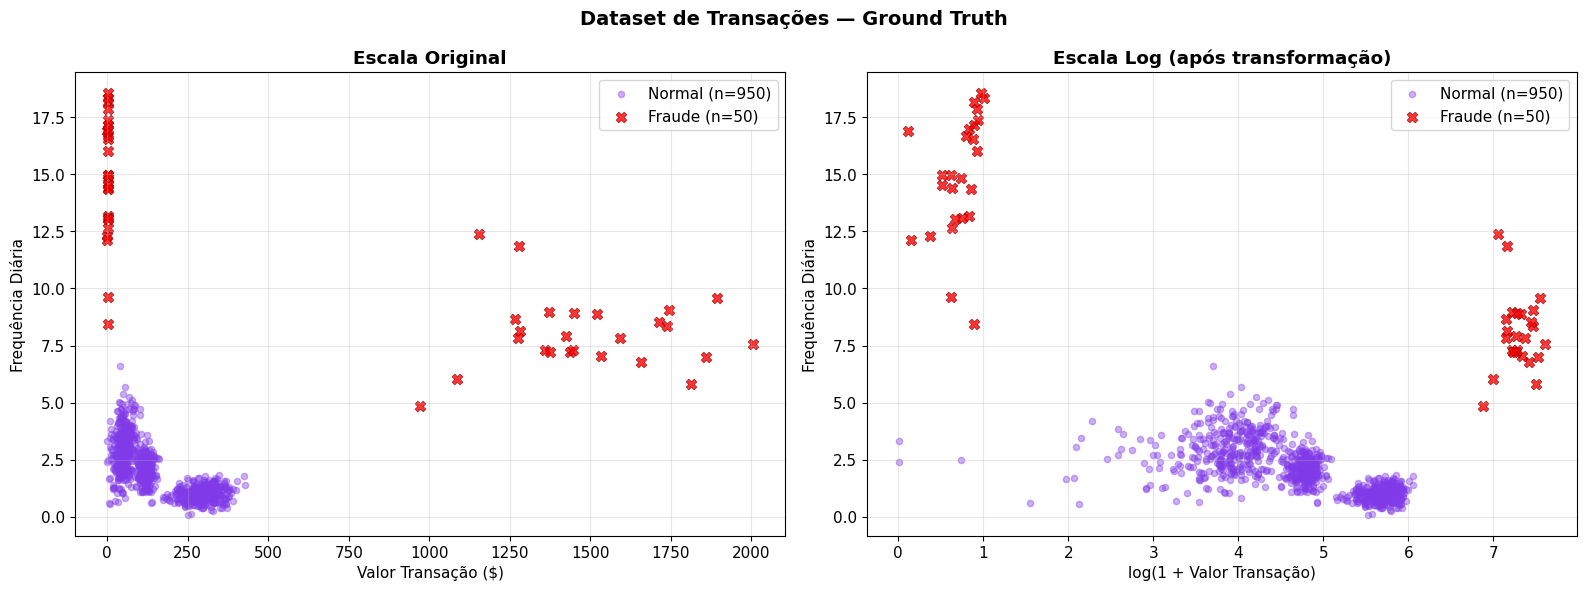

In [26]:
# ─── Visualização do dataset (ground truth) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dataset de Transações — Ground Truth', fontsize=14, fontweight='bold')

for ax, (X_plot, xlabel, title) in zip(axes, [
    (X_fraud_raw, 'Valor Transação ($)', 'Escala Original'),
    (X_fraud_log, 'log(1 + Valor Transação)', 'Escala Log (após transformação)')
]):
    normal_mask = y_true == 0
    fraud_mask  = y_true == 1

    ax.scatter(X_plot[normal_mask, 0], X_plot[normal_mask, 1],
               c=FACENS_COLORS[0], alpha=0.4, s=20, label=f'Normal (n={normal_mask.sum()})')
    ax.scatter(X_plot[fraud_mask, 0], X_plot[fraud_mask, 1],
               c='red', alpha=0.8, s=60, marker='X', label=f'Fraude (n={fraud_mask.sum()})',
               edgecolors='darkred', linewidth=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequência Diária')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fraude_ground_truth.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ─── MÉTODO 1: K-Means + Distância ao Centróide ───────────────────────────────
print('=== Método 1: K-Means + Threshold de Distância ===')

# K-Means treinado apenas nos dados (sem usar os labels)
K_ANOMALY = 3  # 3 clusters de comportamento normal
kmeans_anomaly = KMeans(n_clusters=K_ANOMALY, init='k-means++', n_init=10, random_state=RANDOM_STATE)
kmeans_anomaly.fit(X_fraud_scaled)


=== Método 1: K-Means + Threshold de Distância ===


KMeans(n_clusters=3, n_init=10, random_state=42)

In [29]:
X_fraud_scaled

array([[-0.88377932,  0.09939779],
       [-0.95119877,  0.72998917],
       [-0.61680193,  0.13566925],
       ...,
       [-3.33322261,  5.42699927],
       [-3.69328928,  5.0042878 ],
       [-3.69108539,  4.8375366 ]])

In [32]:

# Calcular distância de cada ponto ao seu centróide mais próximo
distances = np.min(
    np.linalg.norm(
        X_fraud_scaled[:, np.newaxis, :] - kmeans_anomaly.cluster_centers_[np.newaxis, :, :],
        axis=2
    ),
    axis=1
)

print(f'Distância média ao centróide: {distances.mean():.3f}')
print(f'Distância máxima:             {distances.max():.3f}')
print(f'Percentil 95:                 {np.percentile(distances, 95):.3f}')
print(f'Percentil 99:                 {np.percentile(distances, 99):.3f}')

# Threshold: percentil 95 (classificar os 5% mais distantes como anomalia)
THRESHOLD = np.percentile(distances, 95)
y_pred_kmeans = (distances > THRESHOLD).astype(int)

print(f'\nThreshold escolhido (P95): {THRESHOLD:.3f}')
print(f'Predições: {y_pred_kmeans.sum()} anomalias detectadas de {N_TOTAL} transações')

Distância média ao centróide: 0.559
Distância máxima:             4.528
Percentil 95:                 1.092
Percentil 99:                 3.223

Threshold escolhido (P95): 1.092
Predições: 50 anomalias detectadas de 1000 transações


In [33]:
# ─── MÉTODO 2: Isolation Forest ───────────────────────────────────────────────
print('=== Método 2: Isolation Forest ===')

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # proporção esperada de anomalias
    random_state=RANDOM_STATE
)


=== Método 2: Isolation Forest ===


In [36]:
X_fraud_scaled

array([[-0.88377932,  0.09939779],
       [-0.95119877,  0.72998917],
       [-0.61680193,  0.13566925],
       ...,
       [-3.33322261,  5.42699927],
       [-3.69328928,  5.0042878 ],
       [-3.69108539,  4.8375366 ]])

In [37]:
iso_forest.fit(X_fraud_scaled)
y_pred_iso_raw = iso_forest.predict(X_fraud_scaled)  # retorna -1 (anomalia) ou 1 (normal)
y_pred_iso = (y_pred_iso_raw == -1).astype(int)       # converter para 0/1

print(f'Predições: {y_pred_iso.sum()} anomalias detectadas de {N_TOTAL} transações')

# Anomaly scores do Isolation Forest (quanto mais negativo, mais anômalo)
iso_scores = iso_forest.decision_function(X_fraud_scaled)

Predições: 49 anomalias detectadas de 1000 transações


In [38]:
# ─── Avaliação comparativa dos dois métodos ───────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print('=' * 65)
print('AVALIAÇÃO COMPARATIVA — K-Means vs. Isolation Forest')
print('=' * 65)

results = []
for method_name, y_pred in [('K-Means + Threshold', y_pred_kmeans), ('Isolation Forest', y_pred_iso)]:
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    results.append({
        'Método': method_name,
        'Precision': f'{precision:.3f}',
        'Recall': f'{recall:.3f}',
        'F1-Score': f'{f1:.3f}',
        'Fraudes Detectadas': y_pred.sum(),
        'Fraudes Reais': y_true.sum()
    })

    print(f'\n📊 {method_name}')
    print(f'   Precision: {precision:.3f}  (de todo que classifiquei como fraude, {precision*100:.1f}% era fraude mesmo)')
    print(f'   Recall:    {recall:.3f}  (de todas as fraudes reais, detectei {recall*100:.1f}%)')
    print(f'   F1-Score:  {f1:.3f}')
    print(f'\n   Matriz de Confusão:')
    cm = confusion_matrix(y_true, y_pred)
    print(f'   [[TN={cm[0,0]:4d}  FP={cm[0,1]:4d}]')
    print(f'    [FN={cm[1,0]:4d}  TP={cm[1,1]:4d}]]')

print('\n' + '─' * 65)
print('⚠️  Contexto: Em detecção de fraude, Recall é mais crítico que Precision.')
print('    Um FN (fraude não detectada) é pior que um FP (alarme falso).')

AVALIAÇÃO COMPARATIVA — K-Means vs. Isolation Forest

📊 K-Means + Threshold
   Precision: 0.640  (de todo que classifiquei como fraude, 64.0% era fraude mesmo)
   Recall:    0.640  (de todas as fraudes reais, detectei 64.0%)
   F1-Score:  0.640

   Matriz de Confusão:
   [[TN= 932  FP=  18]
    [FN=  18  TP=  32]]

📊 Isolation Forest
   Precision: 0.918  (de todo que classifiquei como fraude, 91.8% era fraude mesmo)
   Recall:    0.900  (de todas as fraudes reais, detectei 90.0%)
   F1-Score:  0.909

   Matriz de Confusão:
   [[TN= 946  FP=   4]
    [FN=   5  TP=  45]]

─────────────────────────────────────────────────────────────────
⚠️  Contexto: Em detecção de fraude, Recall é mais crítico que Precision.
    Um FN (fraude não detectada) é pior que um FP (alarme falso).


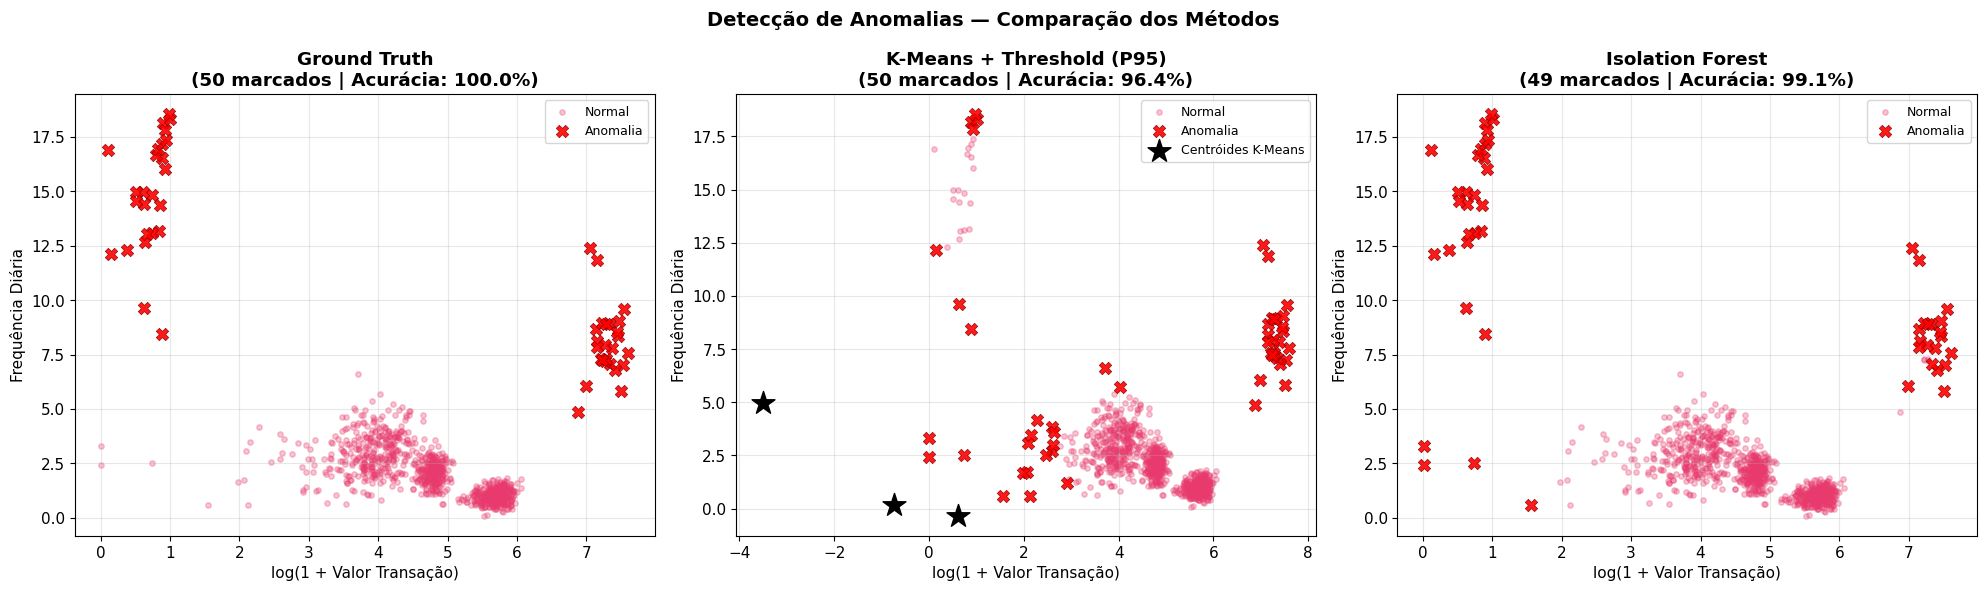

In [39]:
# ─── Visualização comparativa ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Detecção de Anomalias — Comparação dos Métodos', fontsize=14, fontweight='bold')

for ax, (title, y_pred_plot, extra_info) in zip(axes, [
    ('Ground Truth', y_true, None),
    ('K-Means + Threshold (P95)', y_pred_kmeans, distances),
    ('Isolation Forest', y_pred_iso, iso_scores)
]):
    normal_m = y_pred_plot == 0
    fraude_m = y_pred_plot == 1

    ax.scatter(X_fraud_log[normal_m, 0], X_fraud_log[normal_m, 1],
               c=FACENS_COLORS[2], alpha=0.3, s=15, label='Normal')
    ax.scatter(X_fraud_log[fraude_m, 0], X_fraud_log[fraude_m, 1],
               c='red', alpha=0.9, s=80, marker='X', label='Anomalia',
               edgecolors='darkred', linewidth=0.5, zorder=5)

    # Para K-Means, plotar centróides
    if 'K-Means' in title:
        centroids_log = kmeans_anomaly.cluster_centers_
        centroids_orig_scale = scaler_fraud.inverse_transform(centroids_log)
        ax.scatter(centroids_log[:, 0], centroids_log[:, 1],
                   c='black', marker='*', s=300, zorder=10, label='Centróides K-Means')

    n_correct = (y_pred_plot == y_true).sum()
    ax.set_title(f'{title}\n({fraude_m.sum()} marcados | Acurácia: {n_correct/N_TOTAL*100:.1f}%)',
                 fontweight='bold')
    ax.set_xlabel('log(1 + Valor Transação)')
    ax.set_ylabel('Frequência Diária')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('deteccao_anomalias_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ─── Análise do Threshold: como a escolha afeta Precision vs. Recall ─────────
print('=== Análise de Sensibilidade do Threshold (K-Means) ===')
thresholds = [85, 90, 92, 95, 97, 99]
threshold_analysis = []

for p in thresholds:
    thresh = np.percentile(distances, p)
    y_p = (distances > thresh).astype(int)
    prec = precision_score(y_true, y_p, zero_division=0)
    rec  = recall_score(y_true, y_p, zero_division=0)
    f1   = f1_score(y_true, y_p, zero_division=0)
    threshold_analysis.append({'Percentil': f'P{p}', 'Threshold': thresh,
                                 'Anomalias Pred.': y_p.sum(), 'Precision': prec,
                                 'Recall': rec, 'F1': f1})

df_thresh = pd.DataFrame(threshold_analysis)
print(df_thresh.round(3).to_string(index=False))
print('\n💡 Trade-off: Threshold mais baixo → mais recall, menos precision.')
print('   A escolha depende do custo de cada tipo de erro no contexto do negócio.')

=== Análise de Sensibilidade do Threshold (K-Means) ===
Percentil  Threshold  Anomalias Pred.  Precision  Recall    F1
      P85      0.698              150      0.280    0.84 0.420
      P90      0.753              100      0.380    0.76 0.507
      P92      0.824               80      0.475    0.76 0.585
      P95      1.092               50      0.640    0.64 0.640
      P97      1.823               30      0.867    0.52 0.650
      P99      3.223               10      0.800    0.16 0.267

💡 Trade-off: Threshold mais baixo → mais recall, menos precision.
   A escolha depende do custo de cada tipo de erro no contexto do negócio.


---
## 📊 Conclusões e Lições Aprendidas

### Caso 1 — Segmentação de Clientes

| # | Lição |
|---|-------|
| 1 | **Normalização é obrigatória** — sem StandardScaler, features com maior escala dominam a distância |
| 2 | **Múltiplas métricas para escolher K** — Elbow + Silhouette juntos dão confiança na decisão |
| 3 | **EDA guia a escolha de features** — scatter plots podem revelar clusters antes de rodar o algoritmo |
| 4 | **Interpretação de negócio é essencial** — clusters técnicos sem significado comercial não têm valor |

### Caso 2 — Detecção de Anomalias

| # | Lição |
|---|-------|
| 1 | **K-Means pode detectar anomalias** mas é sensível ao threshold escolhido |
| 2 | **Isolation Forest** é mais robusto para anomaly detection por ser projetado para isso |
| 3 | **Transformação log** é essencial quando features têm distribuição muito assimétrica |
| 4 | **Recall é a métrica crítica** em fraude — falsos negativos têm custo alto |

### Próximos Passos Sugeridos

```python
# 1. Testar DBSCAN — não precisa definir K e é robusto a outliers
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)

# 2. Usar t-SNE para visualização de alta dimensionalidade
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

# 3. Pipeline completo com GridSearch para otimizar parâmetros
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
```

---

*Dataset: Mall Customer Segmentation (Kaggle) + Dataset sintético de fraude*